<a href="https://colab.research.google.com/github/dspraneeth07/CognitiveAttackTopology-CAT/blob/main/Notebooks/08_baseline_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Run: 20260307_103759
                model       feature_set   roc_auc  accuracy        f1  \
0  LogisticRegression              text  0.744024   0.66745  0.660438   
1        RandomForest              text  0.928302   0.81200  0.807021   
2             XGBoost              text  0.814686   0.70160  0.611053   
3                 SVM              text  0.681287   0.68160  0.670291   
4           CAT_Model  cognitive_tensor  0.955534   0.85080  0.847957   

   precision    recall  
0   0.666323  0.654656  
1   0.818617  0.795749  
2   0.857980  0.474494  
3   0.686135  0.655162  
4   0.853786  0.842206  
Notebook 08 completed


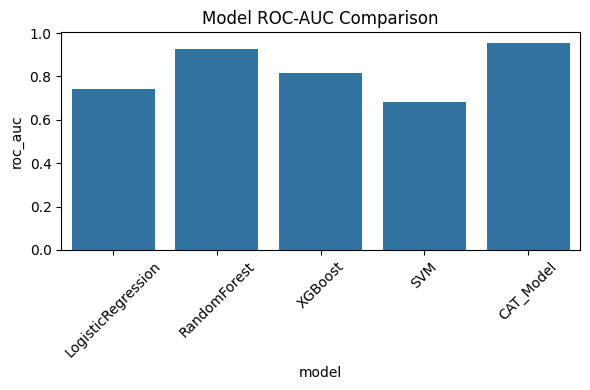

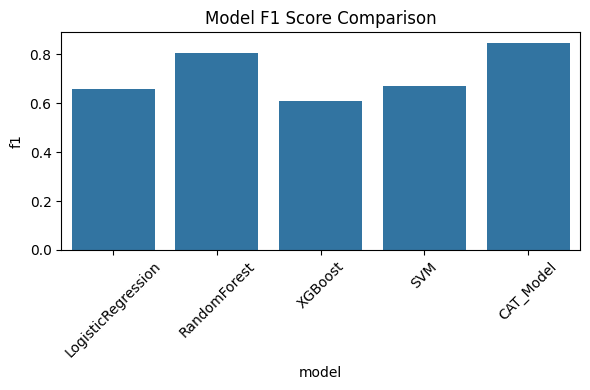

In [2]:
# ===============================================================
# NOTEBOOK 08 — BASELINE MODEL COMPARISON
# CAT Framework Benchmark
# CPU SAFE IMPLEMENTATION
# ===============================================================

!pip -q install pandas numpy scikit-learn seaborn matplotlib xgboost pyarrow

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from datetime import datetime

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier

from google.colab import drive

# ===============================================================
# MOUNT DRIVE
# ===============================================================

drive.mount('/content/drive', force_remount=True)

ROOT = Path("/content/drive/MyDrive/CAT_RESEARCH")

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = ROOT/"runs"/RUN_ID
DATA_DIR = ROOT/"data"

REPORT_DIR = RUN_DIR/"reports"
PLOT_DIR = RUN_DIR/"plots"

for p in [RUN_DIR, REPORT_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Run:",RUN_ID)

# ===============================================================
# LOAD DATASET
# ===============================================================

df = pd.read_parquet(DATA_DIR/"GCT_phase1_100k.parquet")

y = df["human_verified_label"]

# ===============================================================
# TEXT FEATURES (FAST TF-IDF)
# ===============================================================

vectorizer = TfidfVectorizer(
max_features=3000,
ngram_range=(1,2),
stop_words="english"
)

X_text = vectorizer.fit_transform(df["text_transcript"])

# ===============================================================
# COGNITIVE FEATURES
# ===============================================================

X_cog = df[[
"urgency_score",
"fear_trigger_score",
"authority_claim",
"trust_manipulation_score",
"CMS"
]].values

# ===============================================================
# LOAD TDI FEATURE
# ===============================================================

try:
    tdi_file = list(ROOT.glob("runs/*/reports/tdi_performance_metrics.csv"))[-1]
except:
    tdi_file=None

# fallback: compute simple trust variance normalization
sigma = X_cog.std(axis=1)
sigma[sigma==0] = 1e-6
TDI = X_cog.mean(axis=1)/sigma

X_cat = np.column_stack([X_cog,TDI])

# ===============================================================
# DATA SPLIT
# ===============================================================

X_train_txt,X_test_txt,y_train,y_test = train_test_split(
X_text,y,test_size=0.2,stratify=y,random_state=42
)

X_train_cat,X_test_cat,_,_ = train_test_split(
X_cat,y,test_size=0.2,stratify=y,random_state=42
)

# ===============================================================
# MODELS
# ===============================================================

models = {

"LogisticRegression":
LogisticRegression(max_iter=500),

"RandomForest":
RandomForestClassifier(n_estimators=200,n_jobs=-1),

"XGBoost":
XGBClassifier(
n_estimators=200,
max_depth=6,
learning_rate=0.1,
subsample=0.8,
n_jobs=-1
),

"SVM":
LinearSVC()

}

results = []

# ===============================================================
# EVALUATION LOOP
# ===============================================================

for name,model in models.items():

    model.fit(X_train_txt,y_train)

    pred = model.predict(X_test_txt)

    try:
        prob = model.predict_proba(X_test_txt)[:,1]
    except:
        prob = pred

    results.append({

    "model":name,
    "feature_set":"text",

    "roc_auc":roc_auc_score(y_test,prob),
    "accuracy":accuracy_score(y_test,pred),
    "f1":f1_score(y_test,pred),
    "precision":precision_score(y_test,pred),
    "recall":recall_score(y_test,pred)

    })

# ===============================================================
# CAT MODEL (COGNITIVE + TDI)
# ===============================================================

cat_model = RandomForestClassifier(n_estimators=300,n_jobs=-1)

cat_model.fit(X_train_cat,y_train)

pred = cat_model.predict(X_test_cat)

prob = cat_model.predict_proba(X_test_cat)[:,1]

results.append({

"model":"CAT_Model",
"feature_set":"cognitive_tensor",

"roc_auc":roc_auc_score(y_test,prob),
"accuracy":accuracy_score(y_test,pred),
"f1":f1_score(y_test,pred),
"precision":precision_score(y_test,pred),
"recall":recall_score(y_test,pred)

})

# ===============================================================
# RESULTS TABLE
# ===============================================================

results_df = pd.DataFrame(results)

results_df.to_csv(REPORT_DIR/"baseline_model_comparison.csv",index=False)

print(results_df)

# ===============================================================
# ROC VISUALIZATION
# ===============================================================

plt.figure(figsize=(6,4))

sns.barplot(data=results_df,x="model",y="roc_auc")

plt.xticks(rotation=45)

plt.title("Model ROC-AUC Comparison")

plt.tight_layout()

plt.savefig(PLOT_DIR/"model_comparison_roc.png")

# ===============================================================
# F1 VISUALIZATION
# ===============================================================

plt.figure(figsize=(6,4))

sns.barplot(data=results_df,x="model",y="f1")

plt.xticks(rotation=45)

plt.title("Model F1 Score Comparison")

plt.tight_layout()

plt.savefig(PLOT_DIR/"model_comparison_f1.png")

# ===============================================================
# FINAL REPORT
# ===============================================================

best_model = results_df.sort_values("roc_auc",ascending=False).iloc[0]

report = {

"best_model":best_model["model"],
"best_auc":float(best_model["roc_auc"]),
"run_id":RUN_ID

}

with open(REPORT_DIR/"baseline_comparison_report.json","w") as f:

    json.dump(report,f,indent=4)

print("Notebook 08 completed")